In [17]:
import pandas as pd
import numpy as np

# 1. Veriyi Yükleme
df = pd.read_csv("musteri_kayip.csv")

# 2. Modellemeye hiçbir katkısı olmayacak olan Müşteri ID'sini düşürüyoruz
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 3. TotalCharges Sütununu Düzenleme
# Veri setindeki " " (boşluk) karakterlerini NaN yapıp sayısal (float) tipe çeviriyoruz.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Abonelik süresi (tenure) 0 olduğu için TotalCharges boş kalmış, bu yüzden 0 ile dolduruyoruz.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 4. Hedef Değişkeni (Churn) Makine Öğrenmesi İçin Hazırlama
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Adım 1 Tamamlandı!")
print(f"Veri Seti Boyutu: {df.shape}")
print("-" * 30)
print("Eksik Veri Kontrolü (Boş sütun kalmamalı):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Adım 1 Tamamlandı!
Veri Seti Boyutu: (7043, 20)
------------------------------
Eksik Veri Kontrolü (Boş sütun kalmamalı):
Series([], dtype: int64)


In [18]:
# ==========================================
# ADIM 2: ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING)
# ==========================================

# 1. Finansal Oranlar ve Farklar
# tenure 0 olanlarda (yeni müşteriler) sıfıra bölme hatası almamak için koşul ekliyoruz.
df['ucret_per_tenure'] = np.where(df['tenure'] > 0, df['TotalCharges'] / df['tenure'], 0)

# Müşterinin toplam ödemesi ile aylık bazda ödemesi gereken tutar arasındaki fark
df['harcama_farki'] = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])

# 2. Toplam Hizmet Sayısı
# Müşterinin telekom şirketine ne kadar bağlı olduğunu gösterir. Ne kadar çok hizmet, o kadar az kayıp riski.
ek_hizmetler = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

# Sadece 'Yes' olan hizmetleri saydırıyoruz
df['hizmet_sayisi'] = df[ek_hizmetler].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Ana hizmetleri (Telefon ve İnternet) de sayıya ekliyoruz
df['hizmet_sayisi'] += (df['PhoneService'] == 'Yes').astype(int)
df['hizmet_sayisi'] += (df['InternetService'] != 'No').astype(int)

# 3. Yüksek Risk Bayrakları (Kombinasyon Özellikleri)
# Aylık sözleşmesi olup elektronik çek kullananlar (En yüksek terk potansiyeli)
df['risk_kombinasyon'] = ((df['Contract'] == 'Month-to-month') & 
                          (df['PaymentMethod'] == 'Electronic check')).astype(int)

# İnterneti çok hızlı (Fiber) ama güvenlik hizmeti almayanlar (Memnuniyetsizliğe açık grup)
df['fiber_guvenlik_riski'] = ((df['InternetService'] == 'Fiber optic') & 
                              (df['OnlineSecurity'] == 'No')).astype(int)

# 4. Abonelik Süresi (Tenure) Segmentasyonu
def segment_tenure(t):
    if t <= 12:
        return '0-1yil'
    elif t <= 24:
        return '1-2yil'
    elif t <= 48:
        return '2-4yil'
    else:
        return '4yil+'

df['tenure_segment'] = df['tenure'].apply(segment_tenure)

print("Adım 2 Tamamlandı: Özellik Mühendisliği başarıyla uygulandı!")
print(f"Yeni Veri Seti Boyutu: {df.shape}")
print("-" * 30)
print("Eklenen Yeni Özelliklerin Örnek Görünümü:")
print(df[['ucret_per_tenure', 'harcama_farki', 'hizmet_sayisi', 'risk_kombinasyon', 'fiber_guvenlik_riski', 'tenure_segment']].head())

Adım 2 Tamamlandı: Özellik Mühendisliği başarıyla uygulandı!
Yeni Veri Seti Boyutu: (7043, 26)
------------------------------
Eklenen Yeni Özelliklerin Örnek Görünümü:
   ucret_per_tenure  harcama_farki  hizmet_sayisi  risk_kombinasyon  \
0         29.850000           0.00              2                 1   
1         55.573529         -46.80              4                 0   
2         54.075000           0.45              4                 0   
3         40.905556         -62.75              4                 0   
4         75.825000          10.25              2                 1   

   fiber_guvenlik_riski tenure_segment  
0                     0         0-1yil  
1                     0         2-4yil  
2                     0         0-1yil  
3                     0         2-4yil  
4                     1         0-1yil  


In [19]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# ==========================================
# ADIM 3: ENCODING, BÖLME, CSV KAYDETME VE SMOTE
# ==========================================

# 1. X (Özellikler) ve y (Hedef Değişken) Ayırımı
X = df.drop('Churn', axis=1)
y = df['Churn']

# Hedef değişken formatını kontrol etme
if y.dtype == 'object':
    y = y.map({'Yes': 1, 'No': 0})

# 2. One-Hot Encoding 
# Sütun uyumsuzluğu olmaması için (Train'de olup Test'te olmayan kategori sorununu önlemek adına)
# encoding işlemini bölmeden hemen önce tüm veriye uyguluyoruz.
X_encoded = pd.get_dummies(X, drop_first=True)

# XGBoost kolon isimlerinde özel karakter sevmez, temizliyoruz.
X_encoded.columns = [str(col).replace(' ', '_').replace('(', '').replace(')', '').replace('<', '_') for col in X_encoded.columns]

# 3. Train (%80) - Test (%20) Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# ------------------------------------------
# 4. FİZİKSEL CSV DOSYASI OLARAK KAYDETME
# ------------------------------------------
# Kaydetmek için özellikler (X) ve hedef değişkeni (y) yan yana birleştiriyoruz
train_export = pd.concat([X_train, y_train], axis=1)
test_export = pd.concat([X_test, y_test], axis=1)

# Bilgisayara index'leri (satır numaralarını) almadan kaydediyoruz
train_export.to_csv("train_veri.csv", index=False)
test_export.to_csv("test_veri.csv", index=False)

print("✅ Eğitim (%80) ve Test (%20) setleri başarıyla ayrıldı ve CSV olarak kaydedildi!")
print("   -> 'train_veri.csv'")
print("   -> 'test_veri.csv'")
print("-" * 40)
# ------------------------------------------

print("Eğitim Verisi Sınıf Dağılımı (SMOTE Öncesi):")
print(y_train.value_counts())
print("-" * 40)

# 5. SMOTE Uygulaması (SADECE Eğitim Verisine!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Eğitim Verisi Sınıf Dağılımı (SMOTE Sonrası):")
print(y_train_smote.value_counts())
print("-" * 40)
print(f"X_train_smote (SMOTE'lu Eğitim) Boyutu: {X_train_smote.shape}")
print(f"X_test (Test) Boyutu: {X_test.shape}")

✅ Eğitim (%80) ve Test (%20) setleri başarıyla ayrıldı ve CSV olarak kaydedildi!
   -> 'train_veri.csv'
   -> 'test_veri.csv'
----------------------------------------
Eğitim Verisi Sınıf Dağılımı (SMOTE Öncesi):
0    4139
1    1495
Name: Churn, dtype: int64
----------------------------------------
Eğitim Verisi Sınıf Dağılımı (SMOTE Sonrası):
0    4139
1    4139
Name: Churn, dtype: int64
----------------------------------------
X_train_smote (SMOTE'lu Eğitim) Boyutu: (8278, 38)
X_test (Test) Boyutu: (1409, 38)


c:\Users\oguzz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [20]:
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ==========================================
# ADIM 4: MODEL EĞİTİMİ (BASELINE)
# ==========================================

print("Modeller eğitiliyor, lütfen bekleyin...\n")

# 1. XGBoost Modeli
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# 2. CatBoost Modeli (verbose=0 ile eğitimdeki binlerce satır logu gizliyoruz)
cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train_smote, y_train_smote)
cat_pred = cat_model.predict(X_test)
cat_proba = cat_model.predict_proba(X_test)[:, 1]

# 3. Sonuçların Değerlendirilmesi
print("=" * 45)
print("🌟 XGBoost Başarı Raporu 🌟")
print("=" * 45)
print(classification_report(y_test, xgb_pred))
print(f"XGBoost ROC-AUC Skoru: {roc_auc_score(y_test, xgb_proba):.4f}\n")

print("=" * 45)
print("🚀 CatBoost Başarı Raporu 🚀")
print("=" * 45)
print(classification_report(y_test, cat_pred))
print(f"CatBoost ROC-AUC Skoru: {roc_auc_score(y_test, cat_proba):.4f}")

Modeller eğitiliyor, lütfen bekleyin...

🌟 XGBoost Başarı Raporu 🌟
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1035
           1       0.61      0.63      0.62       374

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.80      1409

XGBoost ROC-AUC Skoru: 0.8269

🚀 CatBoost Başarı Raporu 🚀
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1035
           1       0.57      0.61      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.78      1409

CatBoost ROC-AUC Skoru: 0.8315


🏆 MODELİ EN ÇOK ETKİLEYEN İLK 10 ÖZELLİK 🏆
                                Feature  Importance
30                    Contract_Two_year    0.300520
29                    Contract_One_year    0.195680
16                   InternetService_No    0.154101
13       MultipleLines_No_phone_service    0.049195
18                   OnlineSecurity_Yes    0.030311
11                       Dependents_Yes    0.023617
34           PaymentMethod_Mailed_check    0.020917
32  PaymentMethod_Credit_card_automatic    0.019660
24                      TechSupport_Yes    0.017735
12                     PhoneService_Yes    0.014893


C:\Windows\Temp\ipykernel_3308\1869716296.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


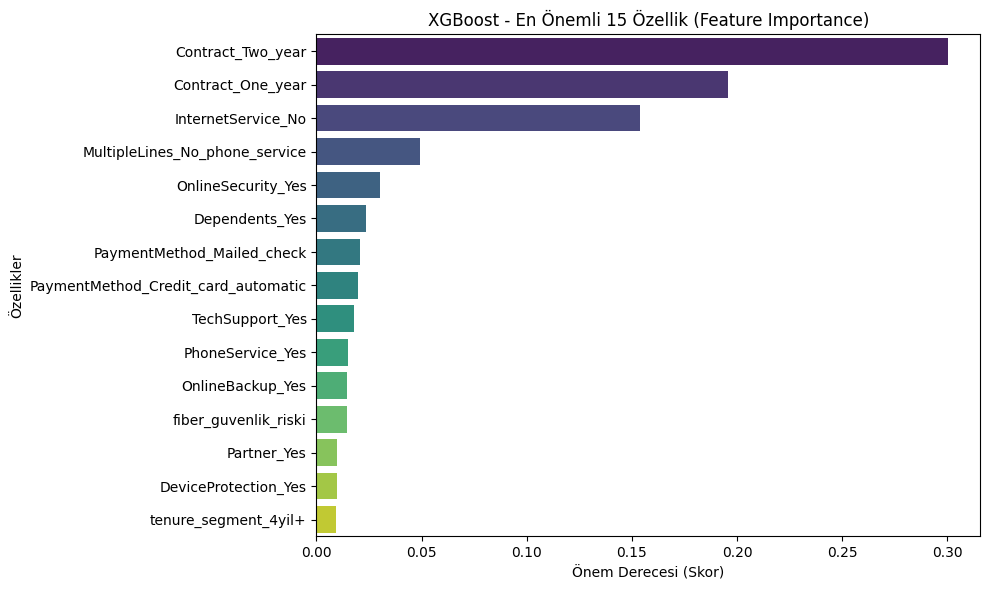

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# ADIM 6: ÖZELLİK ÖNEM DERECELERİ (FEATURE IMPORTANCE)
# ==========================================

# XGBoost'un öğrendiği ağırlıkları alıyoruz
feature_importances = xgb_model.feature_importances_
features = X_train_smote.columns

# DataFrame'e çevirip en yüksekten en düşüğe sıralayalım
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("=" * 40)
print("🏆 MODELİ EN ÇOK ETKİLEYEN İLK 10 ÖZELLİK 🏆")
print("=" * 40)
print(importance_df.head(10))

# Görselleştirme (Eğer bir Jupyter/Colab ortamındaysan grafiği çizer)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('XGBoost - En Önemli 15 Özellik (Feature Importance)')
plt.xlabel('Önem Derecesi (Skor)')
plt.ylabel('Özellikler')
plt.tight_layout()
plt.show()

In [28]:
import pickle
import pandas as pd

# ==========================================
# ADIM 7: MODELİ KAYDETME VE CANLI TEST (SİMÜLASYON)
# ==========================================

# 1. Modeli ve Eğitim Sütunlarını Kaydetme
with open('xgboost_churn_modeli.pkl', 'wb') as f:
    pickle.dump({'model': xgb_model, 'columns': list(X_train_smote.columns)}, f)

print("✅ Model ve Sütun Yapısı bilgisayara başarıyla kaydedildi! ('xgboost_churn_modeli.pkl')\n")

# 2. Canlı Test: Test setinden hayali bir "yeni müşteri" seçelim
# (Gerçek dünyada bu veri web sitesinden veya veritabanından anlık gelir)
ornek_musteri = X_test.iloc[[30]].copy()

# Modelin Olasılık Tahmini Yapması
tahmin_olasiligi = xgb_model.predict_proba(ornek_musteri)[:, 1][0]

# Eğer daha önce optimize ettiysen kendi bulduğun eşik değerini (örn: 0.40) yazabilirsin.
# Burada standart 0.50 eşiğini veya senin bulduğun eşiği kullanabiliriz.
esik_deger = 0.40 
tahmin_sinifi = 1 if tahmin_olasiligi >= esik_deger else 0  

print("========================================")
print("🤖 YENİ MÜŞTERİ RİSK ANALİZİ 🤖")
print("========================================")
print(f"Müşterinin Ayrılma İhtimali: % {tahmin_olasiligi * 100:.1f}")

if tahmin_sinifi == 1:
    print(f"🚨 ALARM: Bu müşteri KAYIP (Churn) potansiyeli taşıyor! (Eşik {esik_deger} aşıldı)")
    print("👉 Aksiyon: Müşteri hizmetleri hemen arayıp 1 yıllık sözleşme indirim kampanyası teklif etmeli.")
else:
    print("✅ GÜVENLİ: Müşterinin ayrılma riski düşük görünüyor.")
    print("👉 Aksiyon: Mevcut hizmet kalitesi korunmalı.")

✅ Model ve Sütun Yapısı bilgisayara başarıyla kaydedildi! ('xgboost_churn_modeli.pkl')

🤖 YENİ MÜŞTERİ RİSK ANALİZİ 🤖
Müşterinin Ayrılma İhtimali: % 44.2
🚨 ALARM: Bu müşteri KAYIP (Churn) potansiyeli taşıyor! (Eşik 0.4 aşıldı)
👉 Aksiyon: Müşteri hizmetleri hemen arayıp 1 yıllık sözleşme indirim kampanyası teklif etmeli.


In [29]:
# ==========================================
# ADIM 8: OTOMATİK MÜŞTERİ İLETİŞİM MOTORU (B2C)
# ==========================================

def otomatik_kampanya_tetikle(musteri_verisi, churn_olasiligi, esik=0.40):
    print("==================================================")
    print("🤖 OTOMATİK PAZARLAMA/İLETİŞİM MOTORU DEVREDE 🤖")
    print("==================================================")
    
    if churn_olasiligi < esik:
        print("SİSTEM KARARI: Müşteri risksiz. Sadece standart aylık bülten (E-Posta) gönderilecek.\n")
        return

    print(f"SİSTEM KARARI: Risk Eşiği Aşıldı (%{churn_olasiligi*100:.1f}). Otomatik mesaj/teklif fırlatılıyor...\n")
    print("📱 MÜŞTERİYE GİDECEK OTOMATİK MESAJ (SMS / PUSH BİLDİRİMİ):")
    print("-" * 50)
    
    # 1. Fatura Şoku + Taahhütsüzlük (En kritik fiyat hassasiyeti)
    is_month_to_month = (musteri_verisi['Contract_One_year'].values[0] == 0) and (musteri_verisi['Contract_Two_year'].values[0] == 0)
    if is_month_to_month and musteri_verisi['MonthlyCharges'].values[0] > 75:
        print("Konu: Fatura Sürprizlerine Son Verin! 🎁")
        print("Mesaj: Değerli Müşterimiz, internet faturanızdaki olası fiyat artışlarından etkilenmemeniz için size özel bir teklifimiz var! Hemen tıklayarak fiyatınızı 1 yıl boyunca sabitleyin, üstelik ilk 2 ay %20 indirim fırsatıyla! [Link]")
        return # En güçlü teklifi bulunca döngüden çık ki müşteri mesaja boğulmasın
        
    # 2. Aile (Dependents) Profili
    if 'Dependents_Yes' in musteri_verisi.columns and musteri_verisi['Dependents_Yes'].values[0] == 1:
        print("Konu: Ailenizin İnternet Güvenliği Bize Emanet 👨‍👩‍👧‍👦")
        print("Mesaj: Değerli Müşterimiz, evinizdeki küçüklerin internette daha güvenli vakit geçirmesi için 'Aile Filtresi ve Çoklu Cihaz Koruma' paketinizi 6 ay boyunca ÜCRETSİZ olarak hesabınıza tanımladık. Güvenle kullanın! [Aktif Et]")
        return

    # 3. Ödeme Sürtünmesi ve Kaçış Kolaylığı
    if 'PaymentMethod_Electronic_check' in musteri_verisi.columns and musteri_verisi['PaymentMethod_Electronic_check'].values[0] == 1:
        print("Konu: Faturanızı Düşürmenin En Kolay Yolu! 💳")
        print("Mesaj: Değerli Müşterimiz, fatura takip etme derdine son! Hemen kredi kartınızla otomatik ödeme talimatı verin, bir sonraki faturanızda anında 50 TL indirim kazanın. İşlemi tamamlamak için: [Link]")
        return
        
    # 4. Eğlence Ekosistemi Eksikliği
    has_streaming = False
    if 'StreamingTV_Yes' in musteri_verisi.columns and 'StreamingMovies_Yes' in musteri_verisi.columns:
        if musteri_verisi['StreamingTV_Yes'].values[0] == 1 or musteri_verisi['StreamingMovies_Yes'].values[0] == 1:
            has_streaming = True
            
    if 'InternetService_Fiber_optic' in musteri_verisi.columns and musteri_verisi['InternetService_Fiber_optic'].values[0] == 1 and not has_streaming:
        print("Konu: Fiber Hızında Sinema Keyfi Hediye! 🎬")
        print("Mesaj: Değerli Müşterimiz, yüksek hızlı fiber internetinizin tadını çıkarmanız için Premium TV ve Sinema paketiniz 1 Ay boyunca bizden! Bu hafta sonu vizyon filmlerinin keyfini çıkarın. Hemen başlat: [Link]")
        return
        
    # 5. Yaşlı (Senior) Müşteri + Teknik Destek Eksikliği
    if 'SeniorCitizen' in musteri_verisi.columns and musteri_verisi['SeniorCitizen'].values[0] == 1 and musteri_verisi['TechSupport_Yes'].values[0] == 0:
        print("Konu: Dijital Dünyada Yalnız Değilsiniz! 📞")
        print("Mesaj: Değerli Müşterimiz, internet bağlantınızla ilgili yardıma ihtiyaç duyduğunuz her an, sıra beklemeden ulaşabileceğiniz VIP Telefon Desteği hattınızı ücretsiz aktif ettik. Destek için bizi arayın: 0850 XXX XX XX")
        return

    # Hiçbir spesifik kurala uymadıysa Genel Kurtarma Mesajı
    print("Konu: Sizi Önemsiyoruz - Özel İndiriminiz Tanımlandı! ⭐")
    print("Mesaj: Değerli Müşterimiz, bizimle olduğunuz için teşekkür ederiz. Sadakatinizi ödüllendirmek amacıyla bir sonraki faturanıza koşulsuz %10 indirim yansıtılmıştır. İyi kullanımlar dileriz!")

# Test Etmek İçin:
# otomatik_kampanya_tetikle(ornek_musteri, tahmin_olasiligi, 0.40)